# Chapter 08 Gradient Boosting: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-08-gradient-boosting-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

A random forest builds hundreds of trees independently and averages them, and that averaging
is what keeps its variance low. Boosting throws that independence away on purpose: each tree
in a boosted ensemble is built to correct the mistakes of the trees that came before it, in
sequence.

The result routinely wins the tabular-data leaderboard that random forests used to dominate.
The trade-off is concrete: a boosted model takes more care to tune than a random forest, and
it can overfit in a way bagging structurally cannot.

This chapter covers what that sequential correction does, and the two implementations,
XGBoost and LightGBM, that turned gradient boosting from a slow research idea into the default
choice for structured data in production.

Recall the rollback-risk scenario from the previous chapter: predicting whether a deployment
will need to be rolled back from payload size, canary error rate, dependency count, and time of
day. The random forest chapter used it to show bagging and variable importance. This chapter
uses the same scenario to show what sequential, error-correcting trees add on top.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(7)

`rollback_risk_data` is a helper used by the figures below.

In [4]:
def rollback_risk_data(n=1200):
    """Simulated deploy records: payload_size, canary_error_rate, dependency_count ->
    a continuous rollback-risk score with nonlinear structure and added noise."""
    payload_kb = RNG.uniform(1, 40, n)
    canary_err = RNG.beta(1.3, 25, n) * 100
    deps = RNG.integers(1, 15, n)
    hour = RNG.integers(0, 24, n)
    risk = (
        0.6 * canary_err
        + 0.15 * np.maximum(payload_kb - 20, 0)
        + 0.4 * deps
        + 3.0 * ((hour >= 0) & (hour <= 5))
        + RNG.normal(0, 3, n)
    )
    X = np.column_stack([payload_kb, canary_err, deps, hour])
    return X, risk

`api_latency_data` is a second helper, used only by the overfitting-curve figure below.

In [5]:
def api_latency_data(n=1500):
    """Simulated production API records: queue_depth, cache_miss_rate, retry_count,
    payload_kb -> response latency in milliseconds, with nonlinear structure and noise.
    Kept separate from rollback_risk_data above so the overfitting-curve figure below
    compares two boosting configurations on its own dataset, not one reused from
    earlier in this chapter."""
    queue_depth = RNG.integers(0, 200, n)
    cache_miss = RNG.beta(2, 6, n)
    retries = RNG.poisson(0.4, n)
    payload_kb = RNG.uniform(1, 60, n)
    latency_ms = (
        0.8 * queue_depth
        + 140 * cache_miss ** 1.5
        + 22 * retries
        + 0.3 * np.maximum(payload_kb - 30, 0) ** 1.2
        + RNG.normal(0, 12, n)
    )
    X = np.column_stack([queue_depth, cache_miss, retries, payload_kb])
    return X, latency_ms

## Shrinkage and the learning-rate trade-off

Training vs. validation loss across boosting rounds, at three learning rates. A high rate overfits and reverses; a low rate takes longer but settles lower. Move the slider.

In [6]:
def fig_shrinkage_early_stopping() -> go.Figure:
    X, y = rollback_risk_data()
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=7)

    learning_rates = [0.5, 0.1, 0.02]
    frames = []
    for lr in learning_rates:
        n_rounds = 300
        model = GradientBoostingRegressor(
            n_estimators=n_rounds, learning_rate=lr, max_depth=2, random_state=7
        )
        model.fit(X_train, y_train)
        train_loss = np.zeros(n_rounds)
        val_loss = np.zeros(n_rounds)
        for i, pred_train in enumerate(model.staged_predict(X_train)):
            train_loss[i] = np.mean((pred_train - y_train) ** 2)
        for i, pred_val in enumerate(model.staged_predict(X_val)):
            val_loss[i] = np.mean((pred_val - y_val) ** 2)
        rounds = np.arange(1, n_rounds + 1)
        best_round = int(np.argmin(val_loss)) + 1
        frames.append(
            go.Frame(
                name=f"{lr}",
                data=[
                    go.Scatter(x=rounds, y=train_loss, mode="lines", name="training loss",
                               line=dict(color="#4C78A8")),
                    go.Scatter(x=rounds, y=val_loss, mode="lines", name="validation loss",
                               line=dict(color="#E45756")),
                ],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=best_round, x1=best_round, y0=0, y1=1,
                                 yref="paper", line=dict(color="#54A24B", width=2, dash="dot"))],
                    annotations=[dict(
                        x=best_round, y=1.05, yref="paper", showarrow=False,
                        text=f"best round: {best_round}", font=dict(color="#54A24B"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[1].data, frames=frames, layout=frames[1].layout)
    fig.update_layout(
        title="Training vs. validation loss across boosting rounds, by learning rate",
        xaxis_title="Boosting round (number of trees added)",
        yaxis_title="Mean squared error",
        sliders=[{
            "active": 1,
            "currentvalue": {"prefix": "Learning rate: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig

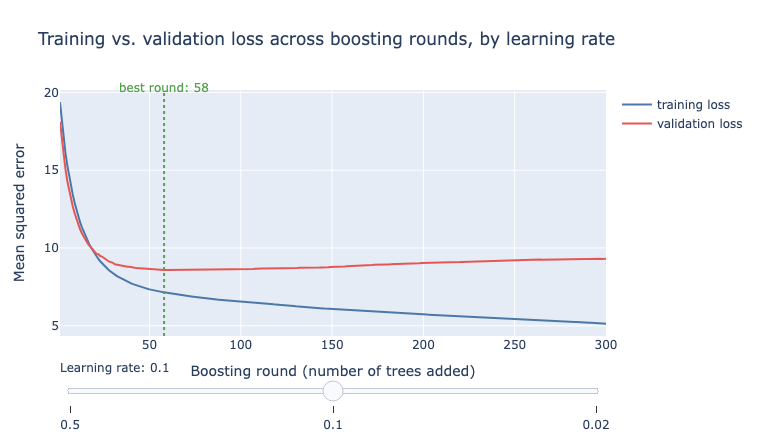

In [7]:
show(fig_shrinkage_early_stopping())

## LightGBM: histogram splits and leaf-wise growth

Training loss for the same leaf budget: leaf-wise growth reaches a lower loss with fewer leaves than level-wise growth needs.

In [8]:
def fig_leafwise_vs_levelwise() -> go.Figure:
    X, y = rollback_risk_data(n=2000)

    def level_wise_loss_curve(max_leaves_seq):
        losses = []
        for depth in range(1, 9):
            tree = DecisionTreeRegressor(max_depth=depth, random_state=7)
            tree.fit(X, y)
            pred = tree.predict(X)
            losses.append((tree.get_n_leaves(), np.mean((pred - y) ** 2)))
        return losses

    def leaf_wise_loss_curve():
        losses = []
        for leaves in range(2, 130, 4):
            tree = DecisionTreeRegressor(max_leaf_nodes=leaves, random_state=7)
            tree.fit(X, y)
            pred = tree.predict(X)
            losses.append((leaves, np.mean((pred - y) ** 2)))
        return losses

    level = level_wise_loss_curve(None)
    leaf = leaf_wise_loss_curve()

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=[p[0] for p in level], y=[p[1] for p in level], mode="lines+markers",
        name="level-wise growth (depth-limited)", line=dict(color="#4C78A8"),
    ))
    fig.add_trace(go.Scatter(
        x=[p[0] for p in leaf], y=[p[1] for p in leaf], mode="lines+markers",
        name="leaf-wise growth (leaf-limited)", line=dict(color="#F58518"),
    ))
    fig.update_layout(
        title="Training loss for the same leaf budget: leaf-wise reaches it faster",
        xaxis_title="Number of leaves in the tree",
        yaxis_title="Training mean squared error",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

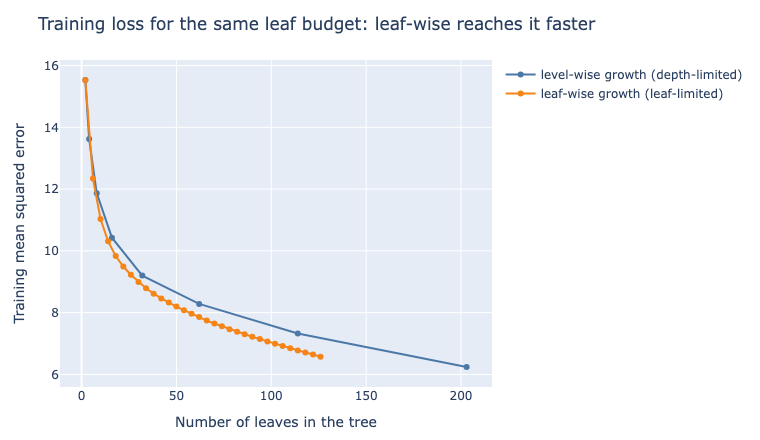

In [9]:
show(fig_leafwise_vs_levelwise())

## A Bayesian perspective

Validation-loss surface over (learning rate, max depth); a search only sees the points it has evaluated so far, and picks the next one by weighing a good predicted score against how unexplored that region still is. Move the slider.

In [10]:
def fig_gp_hyperparameter_search() -> go.Figure:
    X, y = rollback_risk_data()
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=11)

    lr_grid = np.linspace(0.01, 0.5, 12)
    depth_grid = np.arange(1, 7)
    val_loss_grid = np.zeros((len(depth_grid), len(lr_grid)))
    for i, depth in enumerate(depth_grid):
        for j, lr in enumerate(lr_grid):
            model = GradientBoostingRegressor(
                n_estimators=80, learning_rate=lr, max_depth=int(depth), random_state=11
            )
            model.fit(X_train, y_train)
            pred = model.predict(X_val)
            val_loss_grid[i, j] = np.mean((pred - y_val) ** 2)

    rng_order = RNG.permutation(len(lr_grid) * len(depth_grid))
    n_shown_options = [4, 8, 16, 24, len(rng_order)]
    frames = []
    flat_i, flat_j = np.meshgrid(np.arange(len(depth_grid)), np.arange(len(lr_grid)), indexing="ij")
    flat_i, flat_j = flat_i.ravel(), flat_j.ravel()
    for n_shown in n_shown_options:
        chosen = rng_order[:n_shown]
        best_idx = chosen[np.argmin(val_loss_grid[flat_i[chosen], flat_j[chosen]])]
        frames.append(
            go.Frame(
                name=str(n_shown),
                data=[
                    go.Contour(
                        z=val_loss_grid, x=lr_grid, y=depth_grid,
                        colorscale="Blues_r", contours=dict(showlabels=True),
                        opacity=0.55, showscale=False,
                    ),
                    go.Scatter(
                        x=lr_grid[flat_j[chosen]], y=depth_grid[flat_i[chosen]],
                        mode="markers", marker=dict(color="#E45756", size=9),
                        name="evaluated so far",
                    ),
                    go.Scatter(
                        x=[lr_grid[flat_j[best_idx]]], y=[depth_grid[flat_i[best_idx]]],
                        mode="markers", marker=dict(color="#54A24B", size=14, symbol="star"),
                        name="best found",
                    ),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=go.Layout(
        title="Validation-loss surface over (learning rate, max depth); "
              "a search only sees the marked points",
        xaxis_title="Learning rate",
        yaxis_title="Max tree depth",
    ))
    fig.update_layout(
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Hyperparameter combinations evaluated: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig

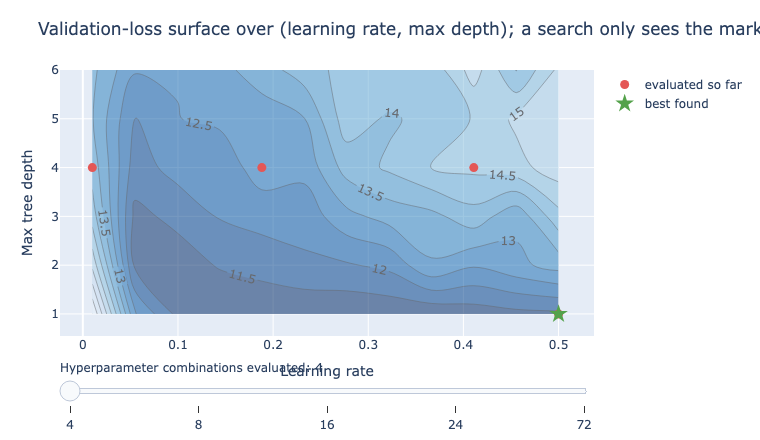

In [11]:
show(fig_gp_hyperparameter_search())

## Random forest, gradient boosting, or LightGBM

Validation error vs. training-set size for a random forest and a gradient boosting model. At the smallest training size the forest has lower error; the two lines cross as the data grows, and gradient boosting pulls ahead with a widening lead at the largest size shown.

In [12]:
def fig_model_comparison_by_dataset_size() -> go.Figure:
    from sklearn.ensemble import RandomForestRegressor

    sizes = [200, 500, 1000, 3000, 8000]
    frames = []
    results = {"Random forest": [], "Gradient boosting (shallow trees)": []}
    for n in sizes:
        X, y = rollback_risk_data(n=n)
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=3)
        rf = RandomForestRegressor(n_estimators=200, random_state=3).fit(X_train, y_train)
        gb = GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=3, random_state=3
        ).fit(X_train, y_train)
        results["Random forest"].append(np.mean((rf.predict(X_val) - y_val) ** 2))
        results["Gradient boosting (shallow trees)"].append(
            np.mean((gb.predict(X_val) - y_val) ** 2)
        )

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=sizes, y=results["Random forest"], mode="lines+markers",
                              name="Random forest", line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=sizes, y=results["Gradient boosting (shallow trees)"],
                              mode="lines+markers", name="Gradient boosting (shallow trees)",
                              line=dict(color="#F58518")))
    fig.update_layout(
        title="Validation error vs. training-set size: random forest and gradient boosting",
        xaxis_title="Training examples",
        yaxis_title="Validation mean squared error",
        xaxis_type="log",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

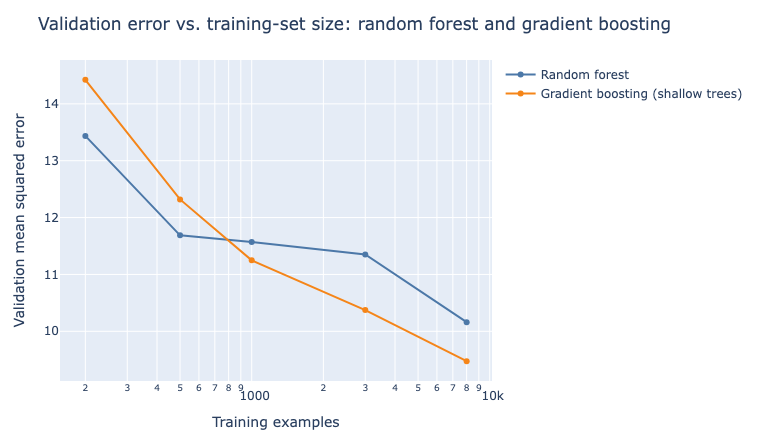

In [13]:
show(fig_model_comparison_by_dataset_size())

## Boosting versus bagging

The running prediction after 1, 5, 20, and 100 boosting rounds on the same data. One round barely moves off a flat line; a hundred rounds trace the underlying curve closely.

In [14]:
def fig_boosting_rounds() -> go.Figure:
    x = np.sort(RNG.uniform(0, 10, size=80))
    y_true = 2 + 3 * np.sin(x / 2)
    y = y_true + RNG.normal(0, 0.5, size=x.shape[0])
    X = x.reshape(-1, 1)

    model = GradientBoostingRegressor(
        n_estimators=100, max_depth=2, learning_rate=0.15, random_state=3
    )
    model.fit(X, y)
    x_grid = np.linspace(0, 10, 200).reshape(-1, 1)
    staged = list(model.staged_predict(x_grid))

    round_checkpoints = [1, 5, 20, 100]
    colors = ["#B7C7DB", "#F58518", "#4C78A8", "#E45756"]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode="markers",
                              marker=dict(color="#DDDDDD", size=6), name="training data",
                              visible=True))
    for i, r in enumerate(round_checkpoints):
        fig.add_trace(go.Scatter(
            x=x_grid.ravel(), y=staged[r - 1], mode="lines",
            line=dict(color=colors[i], width=3), visible=(r == round_checkpoints[0]),
            name=f"after {r} round(s)",
        ))

    steps = []
    for i, r in enumerate(round_checkpoints):
        visible = [True] + [j == i for j in range(len(round_checkpoints))]
        steps.append({"label": str(r), "method": "update", "args": [{"visible": visible}]})

    fig.update_layout(
        title="Each boosting round adds one small tree fit to the current residual",
        xaxis_title="Feature value",
        yaxis_title="Rollback duration (minutes, simulated)",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Boosting rounds: "},
            "steps": steps,
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

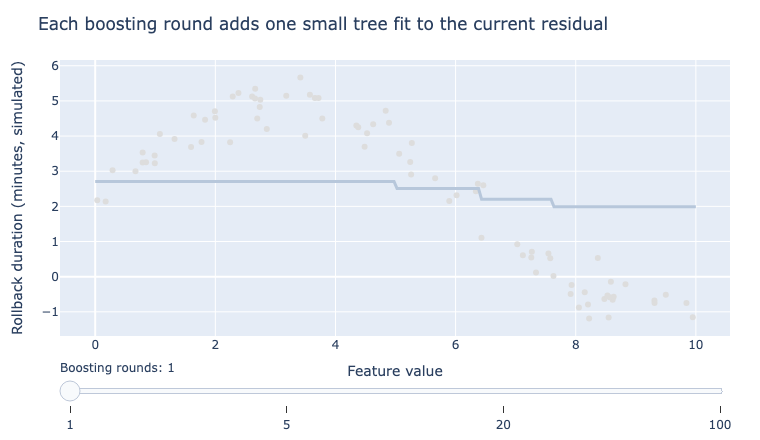

In [15]:
show(fig_boosting_rounds())

## Regularized versus unregularized: an overfitting curve

Training and validation error by boosting round, on 500 API-latency records held out for this comparison, for an unregularized configuration (high learning rate, deep trees) against a regularized one (low learning rate, shallow trees). The unregularized run's validation error turns upward within the first several rounds and plateaus while training error falls to zero; the regularized run's validation error keeps declining through nearly the whole 400-round budget.

In [16]:
def fig_overfitting_curve() -> go.Figure:
    # A smaller sample than the other figures in this chapter use (500 rows, not
    # 1500): overfitting is a small-data problem more than a boosting-specific one,
    # and a smaller training set makes the unregularized run's validation error
    # turn upward clearly instead of only creeping up by a few percent.
    X, y = api_latency_data(n=500)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=21)

    n_rounds = 400
    configs = {
        "Unregularized (lr=0.4, depth=10)": dict(learning_rate=0.4, max_depth=10),
        "Regularized (lr=0.03, depth=2)": dict(learning_rate=0.03, max_depth=2),
    }
    # (validation color, training color) per configuration
    colors = {
        "Unregularized (lr=0.4, depth=10)": ("#E45756", "#F5B5B3"),
        "Regularized (lr=0.03, depth=2)": ("#4C78A8", "#A8C4E0"),
    }

    fig = go.Figure()
    early_stop_round = None
    for label, params in configs.items():
        model = GradientBoostingRegressor(n_estimators=n_rounds, random_state=21, **params)
        model.fit(X_train, y_train)
        train_err = np.array(
            [np.mean((p - y_train) ** 2) for p in model.staged_predict(X_train)]
        )
        val_err = np.array([np.mean((p - y_val) ** 2) for p in model.staged_predict(X_val)])
        rounds = np.arange(1, n_rounds + 1)
        val_color, train_color = colors[label]
        fig.add_trace(go.Scatter(
            x=rounds, y=train_err, mode="lines", name=f"{label}: training error",
            line=dict(color=train_color, dash="dot"),
        ))
        fig.add_trace(go.Scatter(
            x=rounds, y=val_err, mode="lines", name=f"{label}: validation error",
            line=dict(color=val_color),
        ))
        if label.startswith("Regularized"):
            early_stop_round = int(np.argmin(val_err)) + 1

    fig.add_vline(
        x=early_stop_round, line=dict(color="#54A24B", width=2, dash="dash"),
        annotation_text=f"regularized run's best round: {early_stop_round}",
        annotation_position="top left",
    )
    fig.update_layout(
        title="Train vs. validation error by boosting round: the unregularized run "
              "overfits, the regularized run does not",
        xaxis_title="Boosting round",
        yaxis_title="Mean squared error (API latency, ms\u00b2)",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

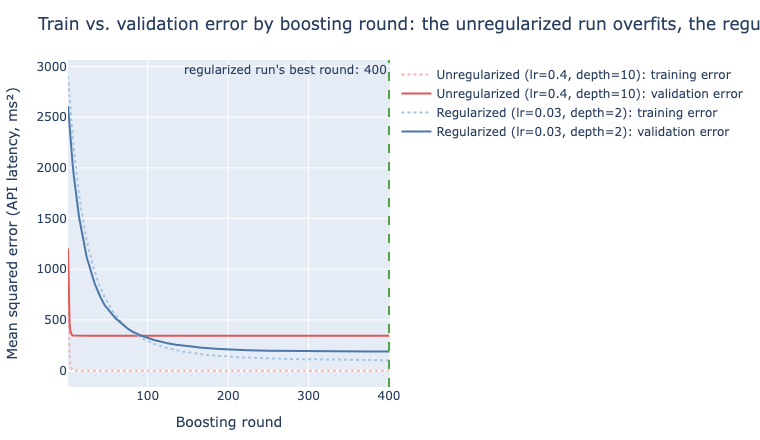

In [17]:
show(fig_overfitting_curve())

## XGBoost: a regularized, second-order boosting system

Training and validation error for the rollback-risk model as XGBoost's `reg_lambda` grows. Training error rises the whole way, since a heavier penalty keeps shrinking every leaf's prediction toward zero; validation error bottoms out around the marked point before creeping back up as the penalty starts blocking signal along with noise.

In [18]:
def fig_xgboost_regularization() -> go.Figure:
    X, y = rollback_risk_data(n=1500)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=13)

    reg_lambda_grid = np.logspace(-2, 3, 18)
    train_loss, val_loss = [], []
    for reg_lambda in reg_lambda_grid:
        model = XGBRegressor(
            n_estimators=150, learning_rate=0.1, max_depth=4,
            reg_lambda=float(reg_lambda), random_state=13,
        )
        model.fit(X_train, y_train)
        train_loss.append(np.mean((model.predict(X_train) - y_train) ** 2))
        val_loss.append(np.mean((model.predict(X_val) - y_val) ** 2))

    best_idx = int(np.argmin(val_loss))

    # A star marker for the best point, not fig.add_vline: add_vline's shape geometry
    # does not compose reliably with a log-scaled x-axis (the vertical line's position
    # gets computed before the axis is set to log, which blew the axis range out to
    # 10^162 in an earlier version of this figure). A scatter marker sidesteps that.
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=reg_lambda_grid, y=train_loss, mode="lines+markers",
                              name="training error", line=dict(color="#4C78A8")))
    fig.add_trace(go.Scatter(x=reg_lambda_grid, y=val_loss, mode="lines+markers",
                              name="validation error", line=dict(color="#E45756")))
    fig.add_trace(go.Scatter(
        x=[reg_lambda_grid[best_idx]], y=[val_loss[best_idx]], mode="markers",
        marker=dict(color="#54A24B", size=14, symbol="star"),
        name=f"lowest validation error (reg_lambda={reg_lambda_grid[best_idx]:.2g})",
    ))
    fig.update_layout(
        title="XGBoost's L2 leaf-weight penalty (reg_lambda): training error keeps rising "
              "while validation error bottoms out, then creeps back up",
        xaxis_title="reg_lambda (L2 penalty on leaf weights)",
        xaxis_type="log",
        yaxis_title="Mean squared error",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

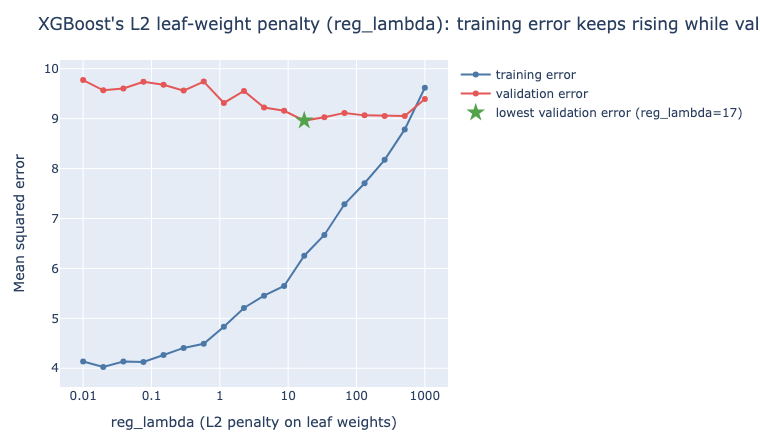

In [19]:
show(fig_xgboost_regularization())